# HeartGuard AI — Heart Disease Prediction Model
## Machine Learning Training Pipeline

This notebook demonstrates the complete ML pipeline used in HeartGuard AI:
1. **Data Loading** — UCI Heart Disease Dataset
2. **Exploratory Data Analysis** — Feature-by-feature impact analysis
3. **Preprocessing** — Box-Cox transformation, One-hot encoding
4. **Model Training** — SVM with GridSearchCV
5. **Evaluation** — Accuracy, Classification Report, Confusion Matrix, ROC
6. **Explainability** — SHAP values for model interpretability
7. **Model Export** — Save for production deployment

In [1]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print('Libraries loaded successfully')

Libraries loaded successfully


## 1. Load Dataset
UCI Cleveland Heart Disease Dataset — 1026 patient records, 13 clinical features.

In [2]:
df = pd.read_csv('../dataset/heart.csv')
print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(10)

Dataset shape: (1025, 14)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


In [3]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [4]:
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing: 0


## 2. Exploratory Data Analysis

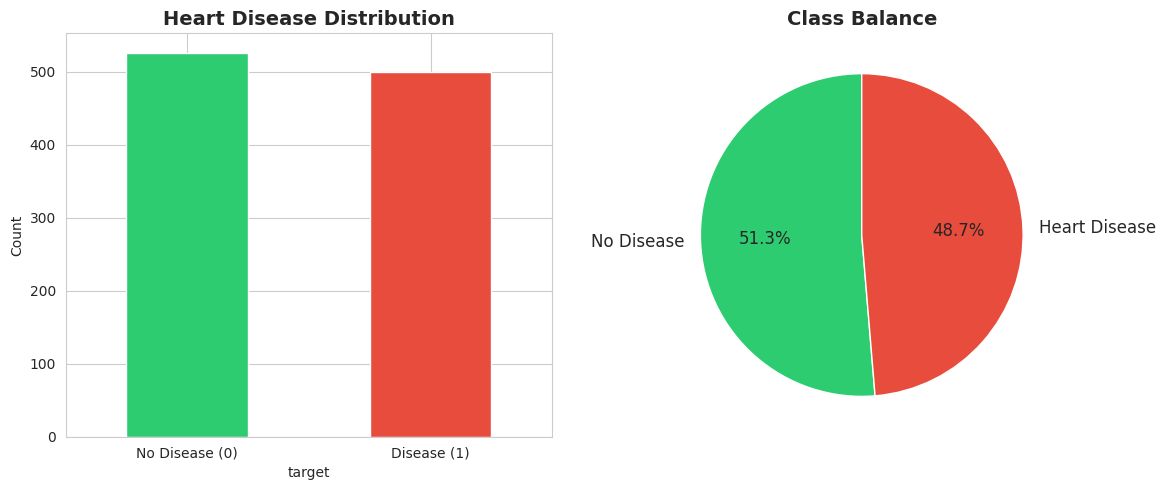

No Disease: 499 (48.7%)
Disease:    526 (51.3%)


In [5]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#2ecc71', '#e74c3c']

df['target'].value_counts().plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Heart Disease Distribution', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['No Disease (0)', 'Disease (1)'], rotation=0)
axes[0].set_ylabel('Count')

df['target'].value_counts().plot(kind='pie', ax=axes[1], colors=colors,
    autopct='%1.1f%%', labels=['No Disease', 'Heart Disease'],
    startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Class Balance', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()
print(f'No Disease: {(df["target"]==0).sum()} ({(df["target"]==0).mean()*100:.1f}%)')
print(f'Disease:    {(df["target"]==1).sum()} ({(df["target"]==1).mean()*100:.1f}%)')

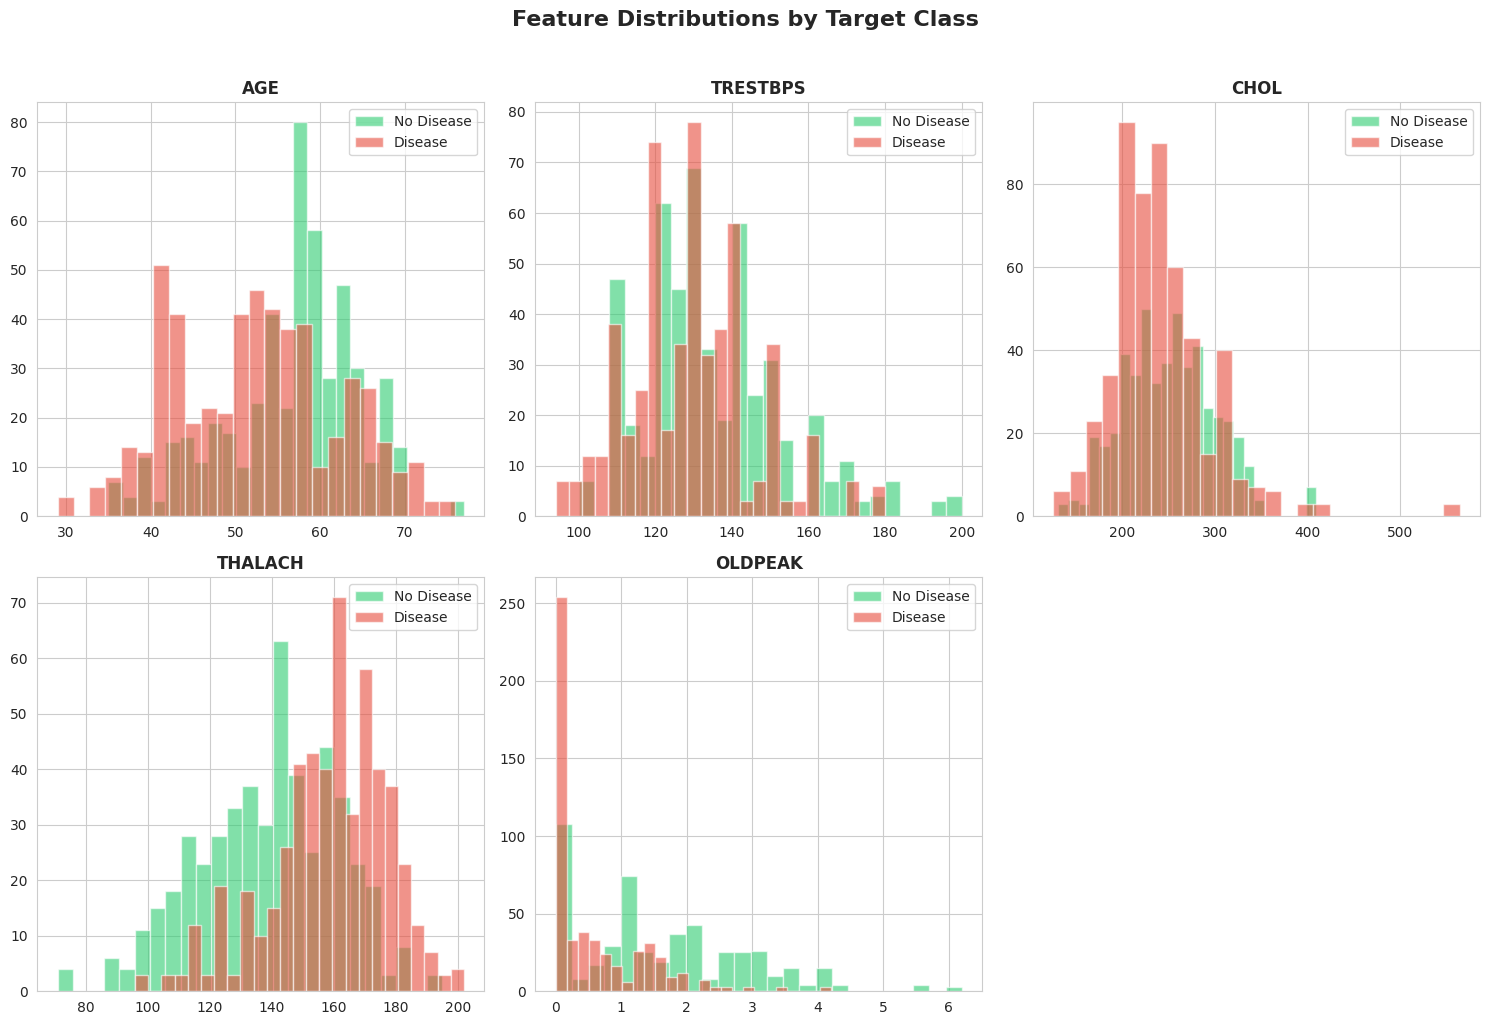

In [6]:
# Feature distributions - Disease vs No Disease
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    axes[i].hist(df[df['target']==0][col], bins=25, alpha=0.6, color='#2ecc71', label='No Disease')
    axes[i].hist(df[df['target']==1][col], bins=25, alpha=0.6, color='#e74c3c', label='Disease')
    axes[i].set_title(col.upper(), fontsize=12, fontweight='bold')
    axes[i].legend()

axes[-1].axis('off')
plt.suptitle('Feature Distributions by Target Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

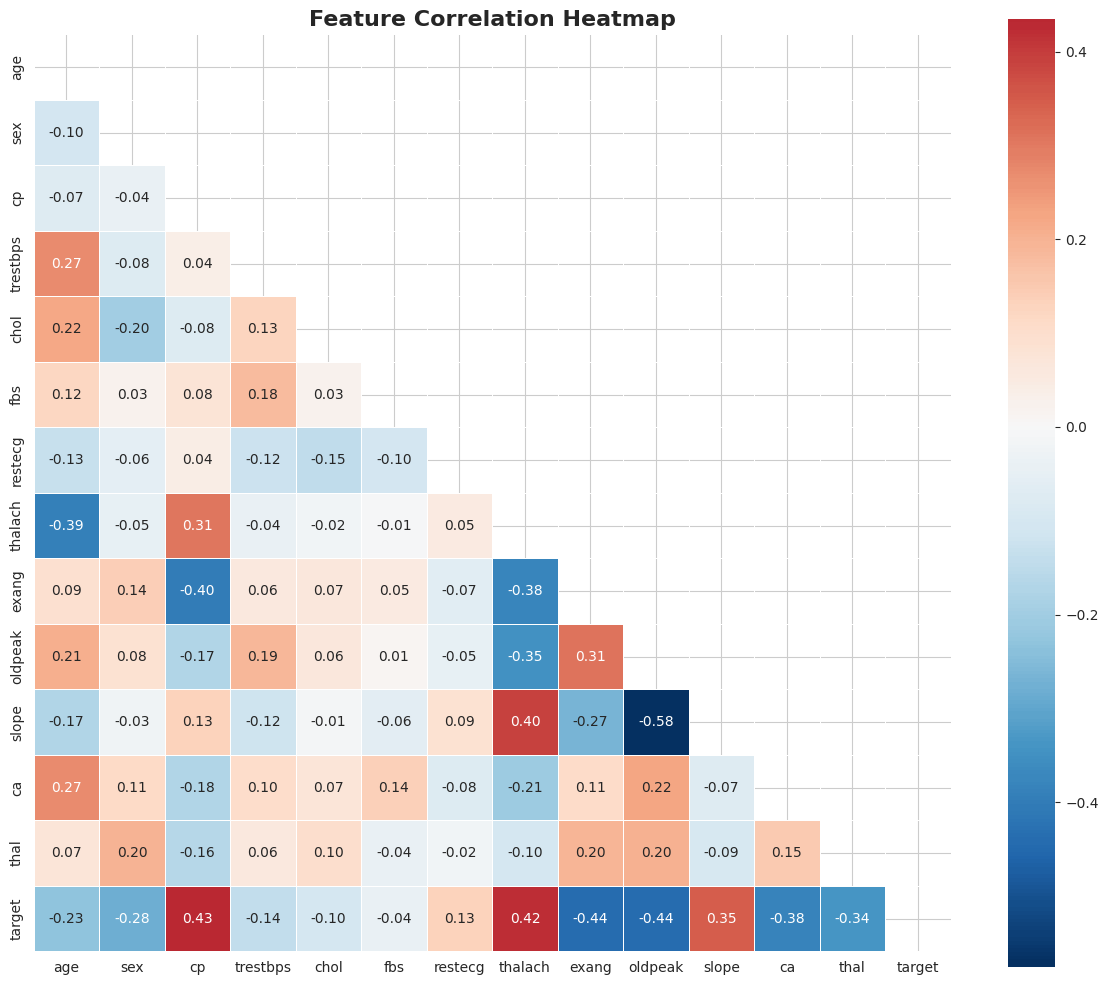

In [7]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.1 Heart Disease Rate by Each Categorical Feature

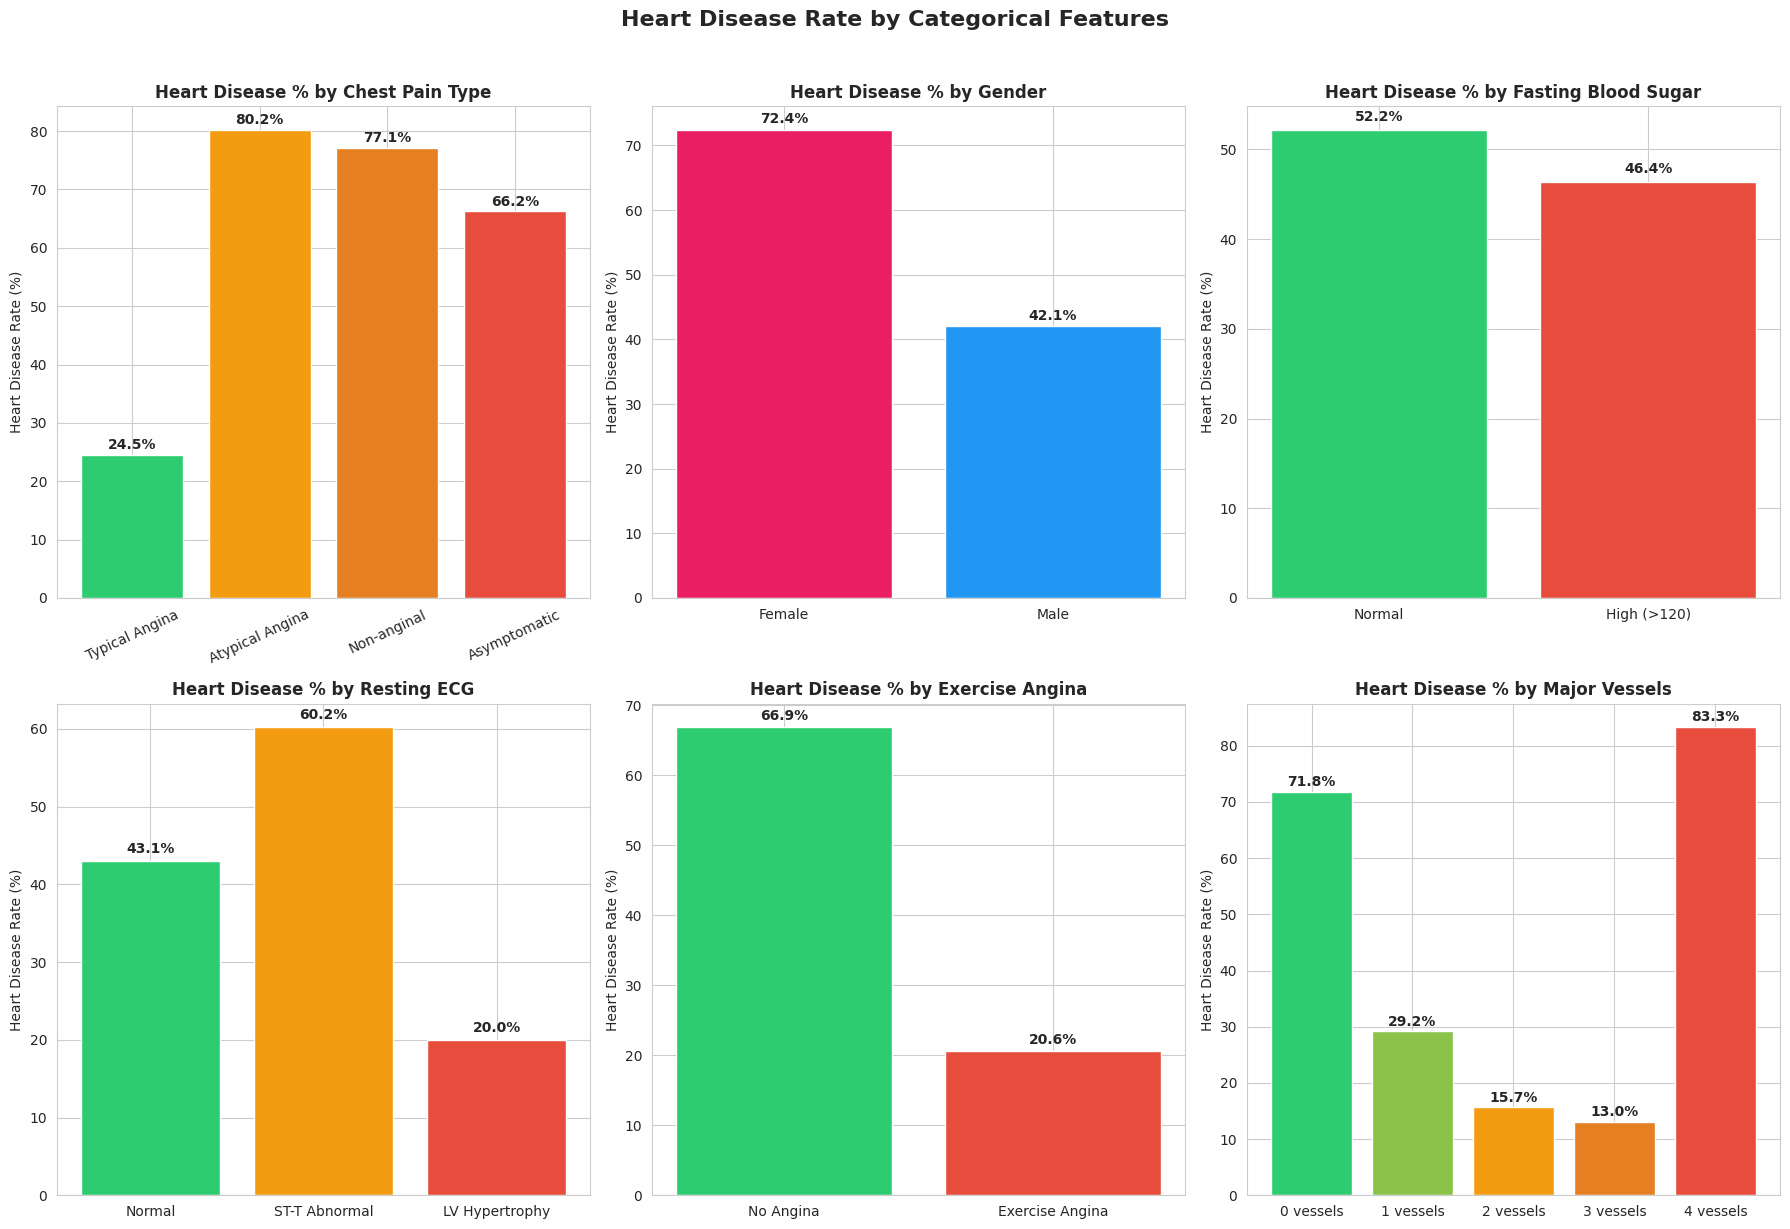

In [8]:
# Heart Disease % by each categorical feature
cp_labels = {0: 'Typical Angina', 1: 'Atypical Angina', 2: 'Non-anginal', 3: 'Asymptomatic'}
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Chest Pain Type
cp_data = df.groupby('cp')['target'].mean() * 100
bars = axes[0,0].bar([cp_labels[i] for i in cp_data.index], cp_data.values, color=['#2ecc71','#f39c12','#e67e22','#e74c3c'])
axes[0,0].set_title('Heart Disease % by Chest Pain Type', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Heart Disease Rate (%)')
axes[0,0].tick_params(axis='x', rotation=25)
for bar, val in zip(bars, cp_data.values):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{val:.1f}%', ha='center', fontweight='bold')

# Gender
sex_data = df.groupby('sex')['target'].mean() * 100
bars = axes[0,1].bar(['Female', 'Male'], sex_data.values, color=['#e91e63','#2196f3'])
axes[0,1].set_title('Heart Disease % by Gender', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Heart Disease Rate (%)')
for bar, val in zip(bars, sex_data.values):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{val:.1f}%', ha='center', fontweight='bold')

# Fasting Blood Sugar
fbs_data = df.groupby('fbs')['target'].mean() * 100
bars = axes[0,2].bar(['Normal', 'High (>120)'], fbs_data.values, color=['#2ecc71','#e74c3c'])
axes[0,2].set_title('Heart Disease % by Fasting Blood Sugar', fontsize=12, fontweight='bold')
axes[0,2].set_ylabel('Heart Disease Rate (%)')
for bar, val in zip(bars, fbs_data.values):
    axes[0,2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{val:.1f}%', ha='center', fontweight='bold')

# Resting ECG
ecg_labels = {0: 'Normal', 1: 'ST-T Abnormal', 2: 'LV Hypertrophy'}
ecg_data = df.groupby('restecg')['target'].mean() * 100
bars = axes[1,0].bar([ecg_labels[i] for i in ecg_data.index], ecg_data.values, color=['#2ecc71','#f39c12','#e74c3c'])
axes[1,0].set_title('Heart Disease % by Resting ECG', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Heart Disease Rate (%)')
for bar, val in zip(bars, ecg_data.values):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{val:.1f}%', ha='center', fontweight='bold')

# Exercise Angina
exang_data = df.groupby('exang')['target'].mean() * 100
bars = axes[1,1].bar(['No Angina', 'Exercise Angina'], exang_data.values, color=['#2ecc71','#e74c3c'])
axes[1,1].set_title('Heart Disease % by Exercise Angina', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Heart Disease Rate (%)')
for bar, val in zip(bars, exang_data.values):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{val:.1f}%', ha='center', fontweight='bold')

# Major Vessels
ca_data = df.groupby('ca')['target'].mean() * 100
bars = axes[1,2].bar([str(i)+' vessels' for i in ca_data.index], ca_data.values, color=['#2ecc71','#8bc34a','#f39c12','#e67e22','#e74c3c'][:len(ca_data)])
axes[1,2].set_title('Heart Disease % by Major Vessels', fontsize=12, fontweight='bold')
axes[1,2].set_ylabel('Heart Disease Rate (%)')
for bar, val in zip(bars, ca_data.values):
    axes[1,2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{val:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Heart Disease Rate by Categorical Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 2.2 Heart Disease by Age Group

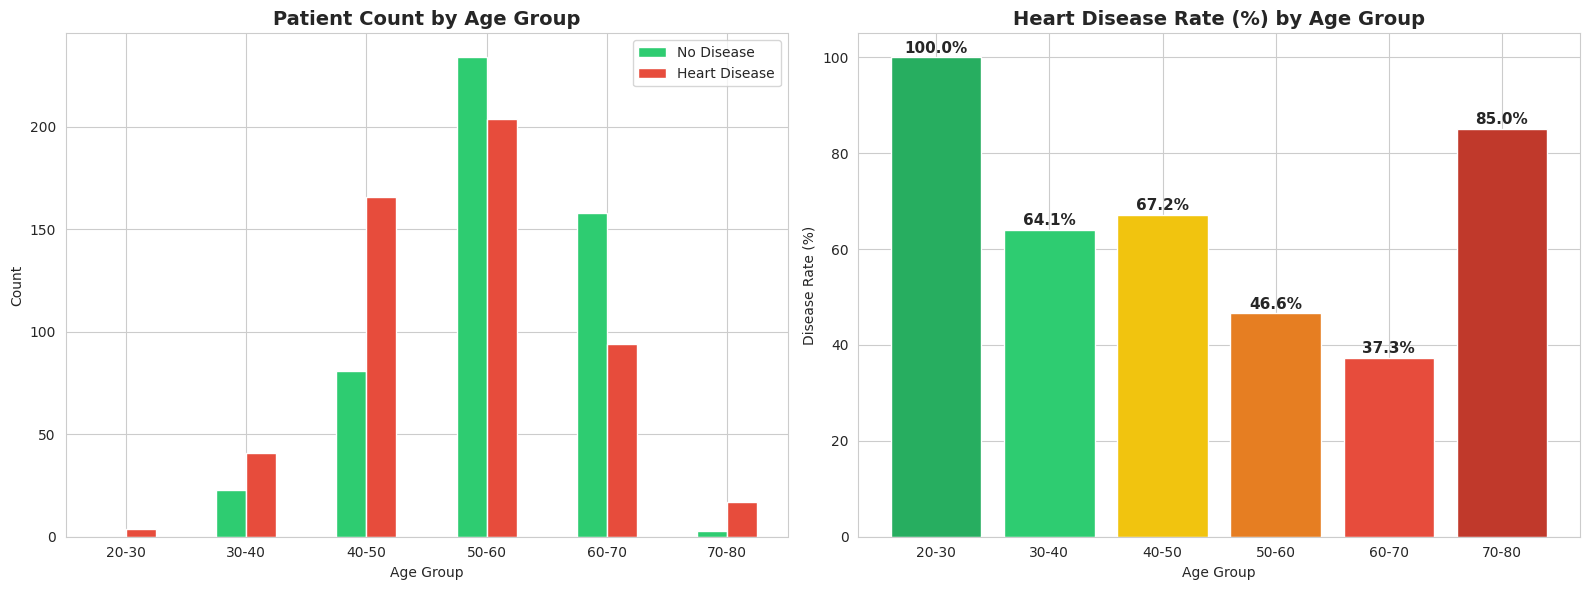

In [9]:
df['age_group'] = pd.cut(df['age'], bins=[20,30,40,50,60,70,80], labels=['20-30','30-40','40-50','50-60','60-70','70-80'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Count by age group
age_counts = df.groupby(['age_group','target']).size().unstack(fill_value=0)
age_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[0].set_title('Patient Count by Age Group', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Count')
axes[0].legend(['No Disease', 'Heart Disease'])
axes[0].tick_params(axis='x', rotation=0)

# Disease rate by age group
age_rate = df.groupby('age_group')['target'].mean() * 100
bars = axes[1].bar(age_rate.index.astype(str), age_rate.values, color=['#27ae60','#2ecc71','#f1c40f','#e67e22','#e74c3c','#c0392b'])
axes[1].set_title('Heart Disease Rate (%) by Age Group', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Disease Rate (%)')
for bar, val in zip(bars, age_rate.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()
df.drop('age_group', axis=1, inplace=True)

### 2.3 Mean Clinical Values — Disease vs No Disease

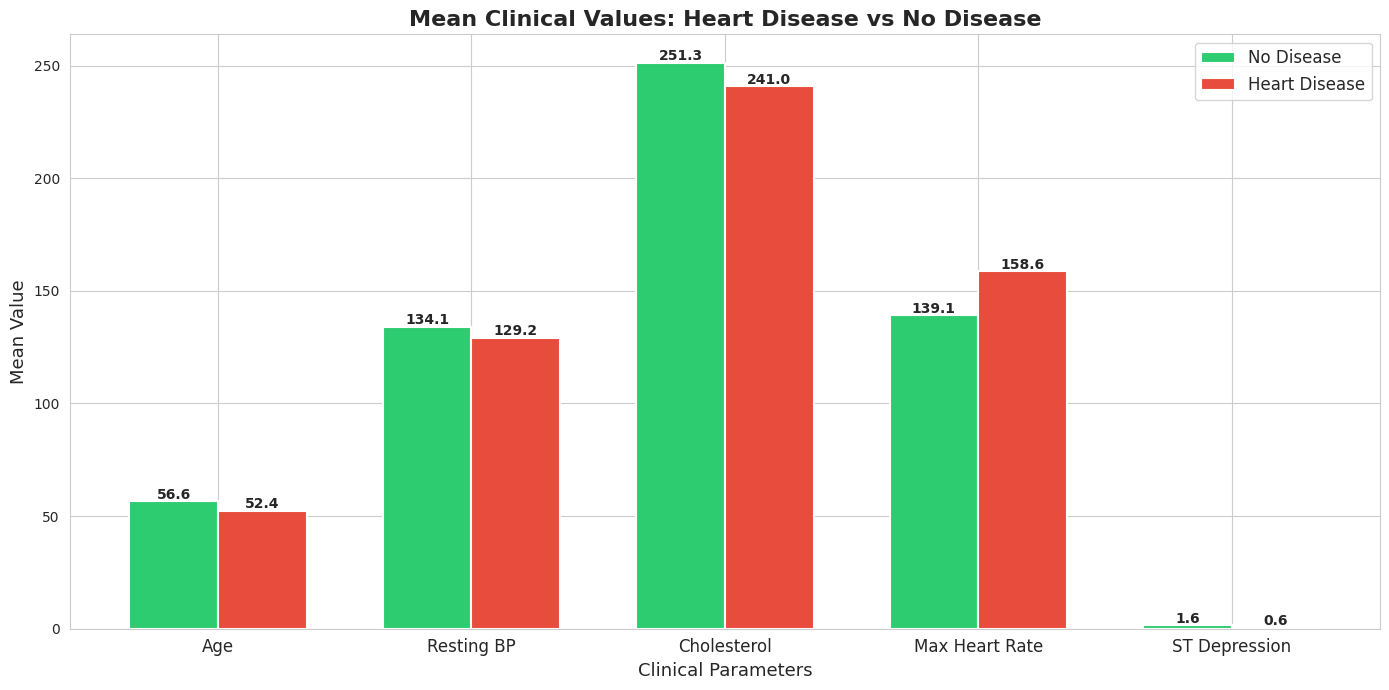


Feature-wise Comparison:
Feature              No Disease      Disease         Difference      Higher In      
--------------------------------------------------------------------------------
Age                  56.57           52.41           -4.16           No Disease     
Resting BP           134.11          129.25          -4.86           No Disease     
Cholesterol          251.29          240.98          -10.31          No Disease     
Max Heart Rate       139.13          158.59          +19.46          Disease        
ST Depression        1.60            0.57            -1.03           No Disease     


In [10]:
features_to_compare = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
labels = ['Age', 'Resting BP', 'Cholesterol', 'Max Heart Rate', 'ST Depression']

disease_means = df[df['target']==1][features_to_compare].mean()
no_disease_means = df[df['target']==0][features_to_compare].mean()

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
bars1 = ax.bar(x - width/2, no_disease_means.values, width, label='No Disease', color='#2ecc71', edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x + width/2, disease_means.values, width, label='Heart Disease', color='#e74c3c', edgecolor='white', linewidth=1.5)

ax.set_xlabel('Clinical Parameters', fontsize=13)
ax.set_ylabel('Mean Value', fontsize=13)
ax.set_title('Mean Clinical Values: Heart Disease vs No Disease', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.legend(fontsize=12)

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{bar.get_height():.1f}', ha='center', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{bar.get_height():.1f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nFeature-wise Comparison:')
print(f'{"Feature":<20} {"No Disease":<15} {"Disease":<15} {"Difference":<15} {"Higher In":<15}')
print('-' * 80)
for feat, label in zip(features_to_compare, labels):
    nd = no_disease_means[feat]
    d = disease_means[feat]
    diff = d - nd
    higher = 'Disease' if diff > 0 else 'No Disease'
    print(f'{label:<20} {nd:<15.2f} {d:<15.2f} {diff:<+15.2f} {higher:<15}')

### 2.4 Top Risk Factors — Feature Importance by Correlation

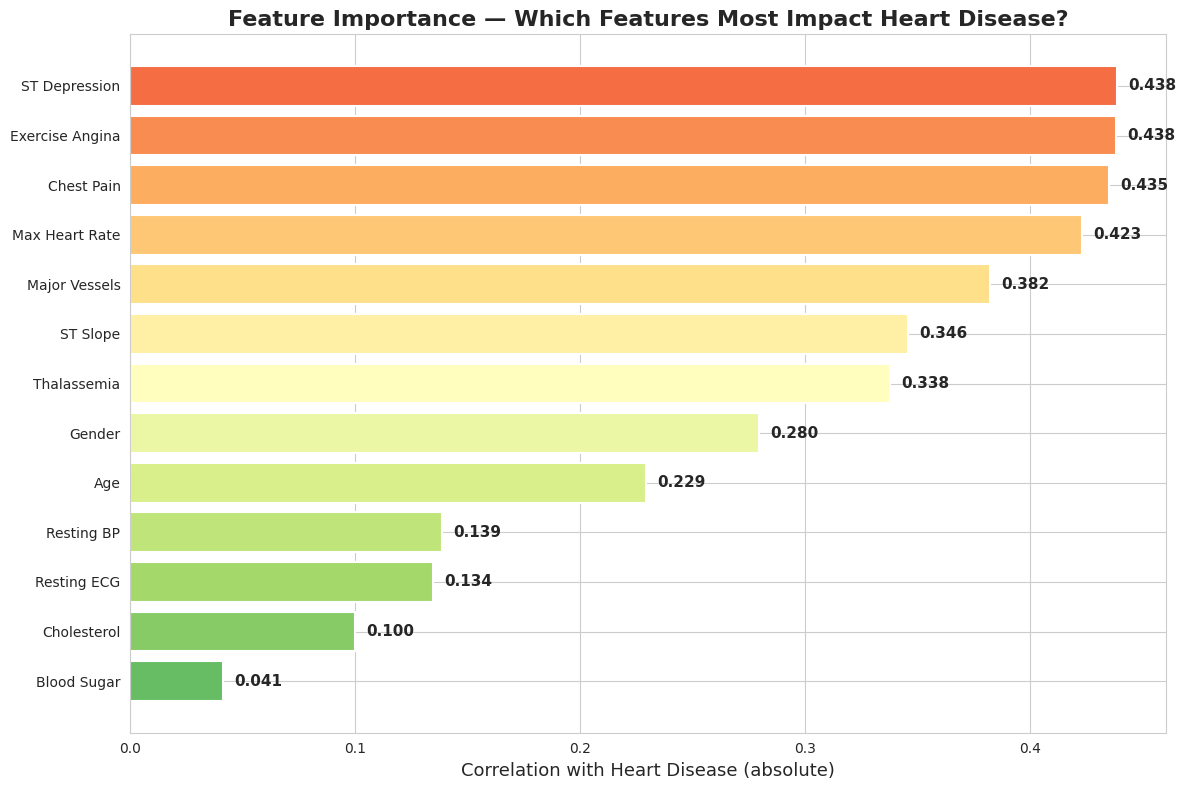


Top 5 Most Important Features for Heart Disease:
  1. ST Depression: 0.438
  2. Exercise Angina: 0.438
  3. Chest Pain: 0.435
  4. Max Heart Rate: 0.423
  5. Major Vessels: 0.382


In [11]:
feature_labels = {
    'age': 'Age', 'sex': 'Gender', 'cp': 'Chest Pain', 'trestbps': 'Resting BP',
    'chol': 'Cholesterol', 'fbs': 'Blood Sugar', 'restecg': 'Resting ECG',
    'thalach': 'Max Heart Rate', 'exang': 'Exercise Angina', 'oldpeak': 'ST Depression',
    'slope': 'ST Slope', 'ca': 'Major Vessels', 'thal': 'Thalassemia'
}

all_feats = list(feature_labels.keys())
correlations = df[all_feats].corrwith(df['target']).abs().sort_values(ascending=True)

plt.figure(figsize=(12, 8))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(correlations)))
bars = plt.barh([feature_labels.get(f, f) for f in correlations.index], correlations.values, color=colors, edgecolor='white', linewidth=1.5)
plt.xlabel('Correlation with Heart Disease (absolute)', fontsize=13)
plt.title('Feature Importance — Which Features Most Impact Heart Disease?', fontsize=16, fontweight='bold')

for bar, val in zip(bars, correlations.values):
    plt.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

print('\nTop 5 Most Important Features for Heart Disease:')
for i, (feat, corr) in enumerate(correlations.tail(5).iloc[::-1].items(), 1):
    print(f'  {i}. {feature_labels.get(feat, feat)}: {corr:.3f}')

### 2.5 Detailed Feature Analysis — Box Plots & Violin Plots

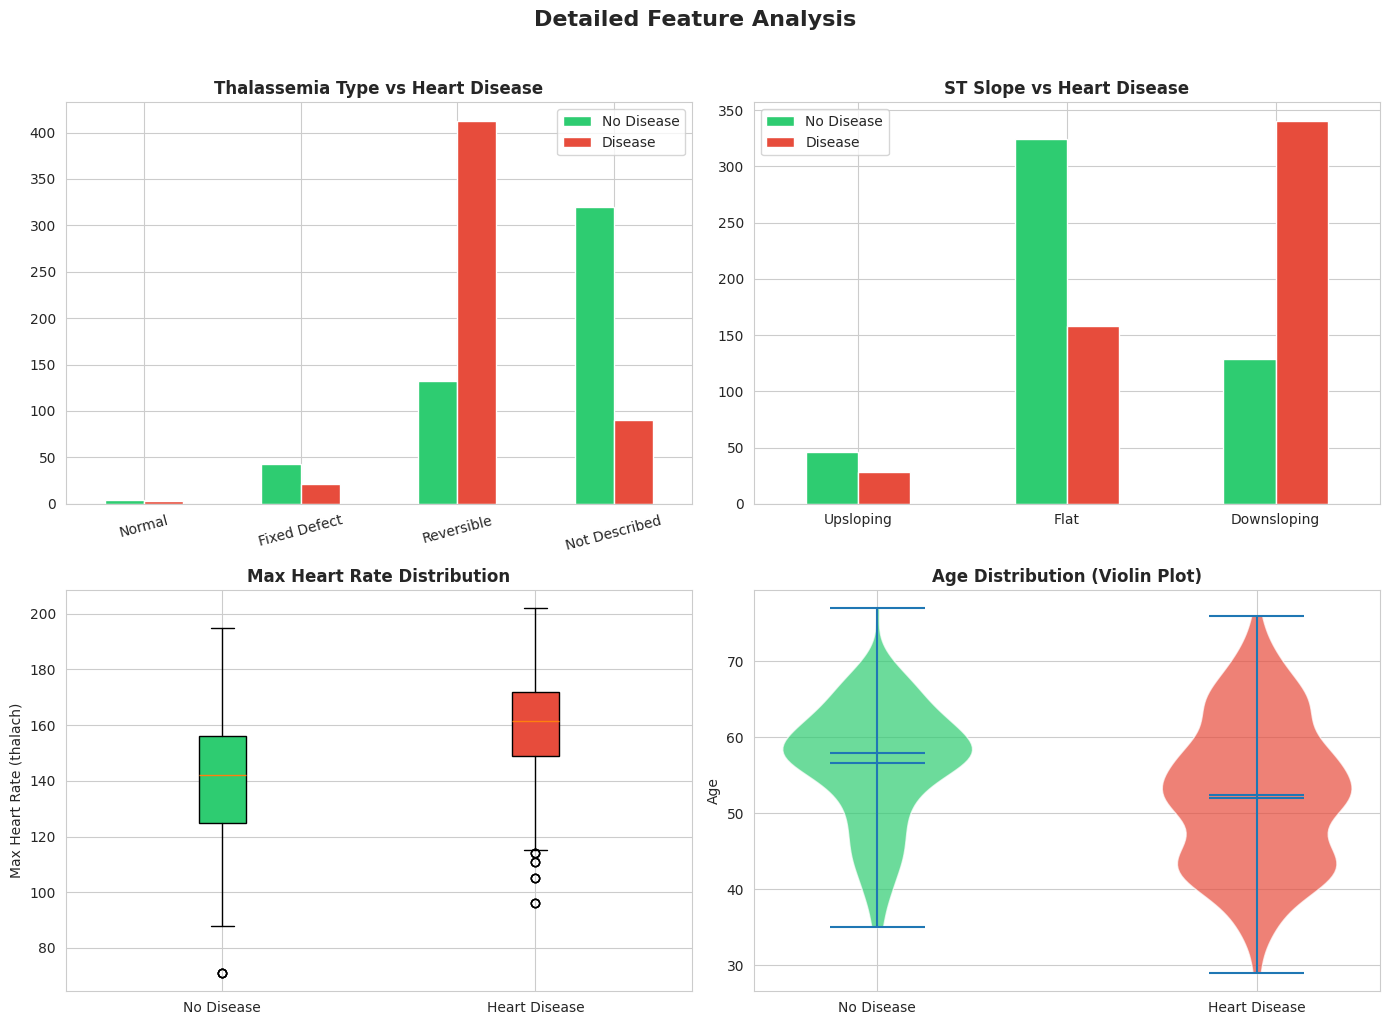

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Thalassemia types
thal_labels = {0: 'Normal', 1: 'Fixed Defect', 2: 'Reversible', 3: 'Not Described'}
thal_disease = df.groupby('thal')['target'].value_counts().unstack(fill_value=0)
thal_disease.index = [thal_labels.get(i, str(i)) for i in thal_disease.index]
thal_disease.plot(kind='bar', ax=axes[0,0], color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[0,0].set_title('Thalassemia Type vs Heart Disease', fontsize=12, fontweight='bold')
axes[0,0].legend(['No Disease', 'Disease'])
axes[0,0].tick_params(axis='x', rotation=15)

# ST Slope
slope_labels = {0: 'Upsloping', 1: 'Flat', 2: 'Downsloping'}
slope_disease = df.groupby('slope')['target'].value_counts().unstack(fill_value=0)
slope_disease.index = [slope_labels.get(i, str(i)) for i in slope_disease.index]
slope_disease.plot(kind='bar', ax=axes[0,1], color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[0,1].set_title('ST Slope vs Heart Disease', fontsize=12, fontweight='bold')
axes[0,1].legend(['No Disease', 'Disease'])
axes[0,1].tick_params(axis='x', rotation=0)

# Max Heart Rate boxplot
bp = axes[1,0].boxplot([df[df['target']==0]['thalach'], df[df['target']==1]['thalach']],
                   labels=['No Disease', 'Heart Disease'], patch_artist=True)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
axes[1,0].set_title('Max Heart Rate Distribution', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Max Heart Rate (thalach)')

# Age violin
parts = axes[1,1].violinplot([df[df['target']==0]['age'], df[df['target']==1]['age']],
                              positions=[1,2], showmeans=True, showmedians=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(['#2ecc71','#e74c3c'][i])
    pc.set_alpha(0.7)
axes[1,1].set_xticks([1,2])
axes[1,1].set_xticklabels(['No Disease', 'Heart Disease'])
axes[1,1].set_title('Age Distribution (Violin Plot)', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Age')

plt.suptitle('Detailed Feature Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

In [13]:
original_len = len(df)
df_clean = df.drop_duplicates()
print(f'Removed {original_len - len(df_clean)} duplicates -> {len(df_clean)} samples remaining')

X = df_clean.drop('target', axis=1)
y = df_clean['target']

X['oldpeak'] = X['oldpeak'] + 0.001
X = pd.get_dummies(X, columns=['cp', 'restecg', 'thal'], drop_first=True)

print(f'Features after encoding: {X.shape[1]}')
print(f'Columns: {list(X.columns)}')

Removed 723 duplicates -> 302 samples remaining
Features after encoding: 18
Columns: ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'cp_1', 'cp_2', 'cp_3', 'restecg_1', 'restecg_2', 'thal_1', 'thal_2', 'thal_3']


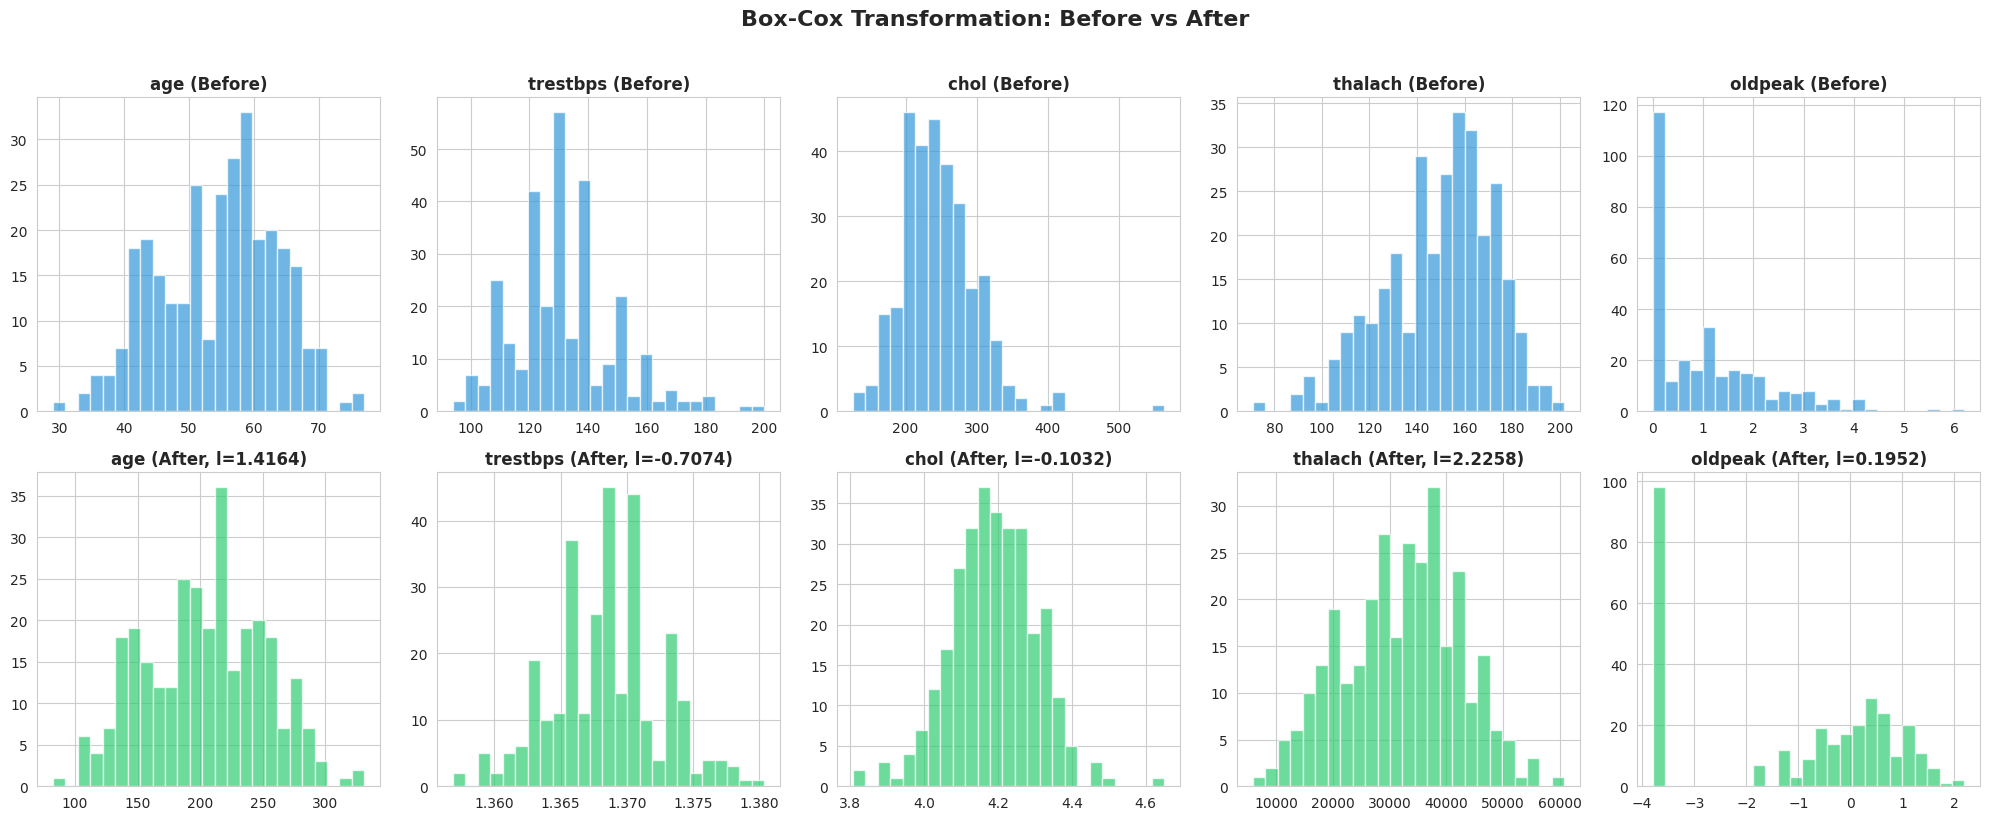


Box-Cox Lambda Values:
  age: lambda = 1.4164
  trestbps: lambda = -0.7074
  chol: lambda = -0.1032
  thalach: lambda = 2.2258
  oldpeak: lambda = 0.1952


In [14]:
# Box-Cox Transformation
boxcox_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
lambdas = {}

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, col in enumerate(boxcox_features):
    axes[0, i].hist(X[col], bins=25, color='#3498db', alpha=0.7)
    axes[0, i].set_title(f'{col} (Before)', fontweight='bold')
    
    vals = X[col].values.astype(float)
    vals = np.where(vals <= 0, abs(vals) + 0.001, vals)
    transformed, lmbda = boxcox(vals)
    X[col] = transformed
    lambdas[col] = lmbda
    
    axes[1, i].hist(X[col], bins=25, color='#2ecc71', alpha=0.7)
    axes[1, i].set_title(f'{col} (After, l={lmbda:.4f})', fontweight='bold')

plt.suptitle('Box-Cox Transformation: Before vs After', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\nBox-Cox Lambda Values:')
for col, lmbda in lambdas.items():
    print(f'  {col}: lambda = {lmbda:.4f}')

## 4. Model Training

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')

Training set: 241 samples
Test set:     61 samples


In [16]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(probability=True, random_state=42))
])

param_grid = {
    'clf__C': [0.1, 1, 10, 100],
    'clf__gamma': ['scale', 'auto', 0.01, 0.1],
    'clf__kernel': ['rbf', 'linear'],
}

print('Training SVM with GridSearchCV (5-fold CV)...')
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f'\nBest parameters: {grid_search.best_params_}')
print(f'Best CV accuracy: {grid_search.best_score_:.4f} ({grid_search.best_score_*100:.1f}%)')

Training SVM with GridSearchCV (5-fold CV)...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

Best parameters: {'clf__C': 1, 'clf__gamma': 0.01, 'clf__kernel': 'rbf'}
Best CV accuracy: 0.8214 (82.1%)


## 5. Model Evaluation

In [17]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]
test_accuracy = accuracy_score(y_test, y_pred)

print(f'Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.1f}%)')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Heart Disease']))

Test Accuracy: 0.8361 (83.6%)

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.85      0.79      0.81        28
Heart Disease       0.83      0.88      0.85        33

     accuracy                           0.84        61
    macro avg       0.84      0.83      0.83        61
 weighted avg       0.84      0.84      0.84        61



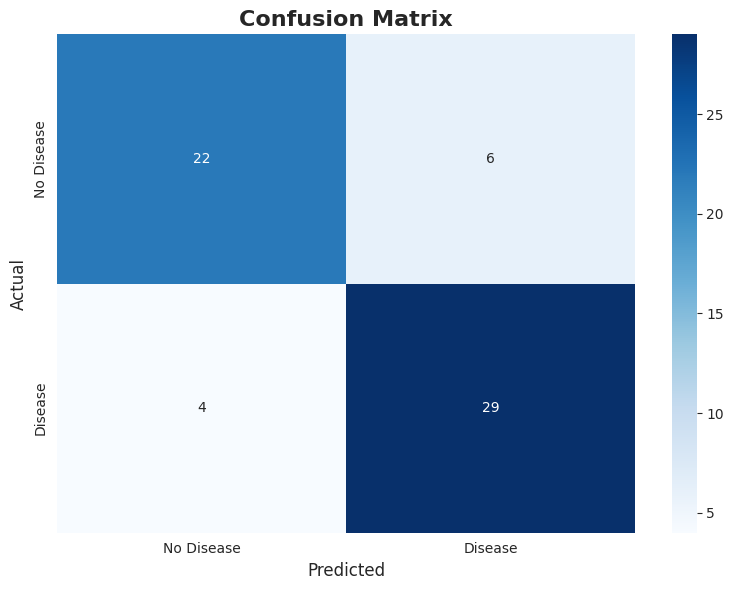

True Negatives:  22  |  False Positives: 6
False Negatives: 4  |  True Positives:  29
Sensitivity (Recall): 0.8788
Specificity:          0.7857


In [18]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives:  {tn}  |  False Positives: {fp}')
print(f'False Negatives: {fn}  |  True Positives:  {tp}')
print(f'Sensitivity (Recall): {tp/(tp+fn):.4f}')
print(f'Specificity:          {tn/(tn+fp):.4f}')

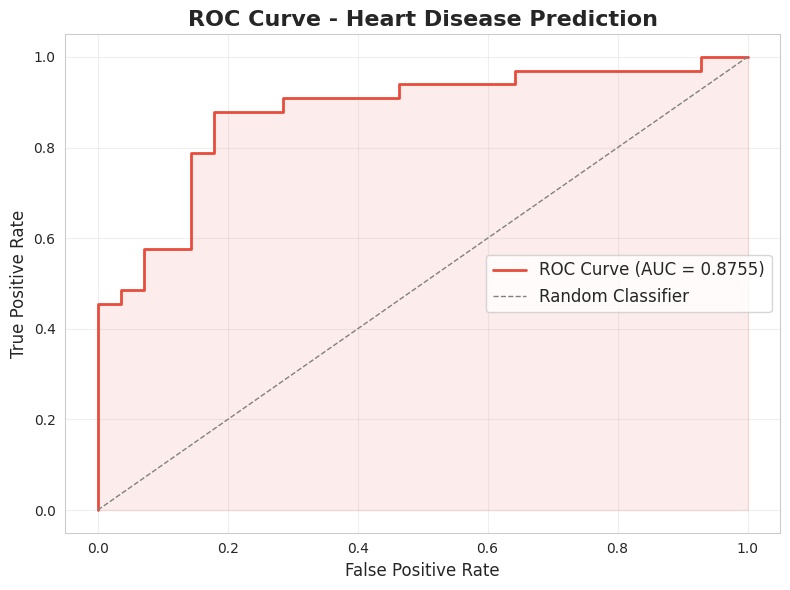

In [19]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Heart Disease Prediction', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

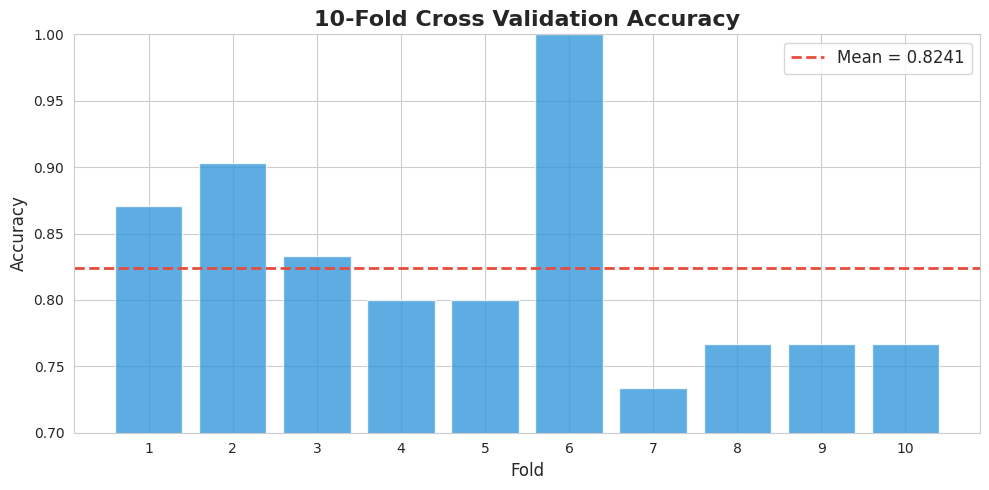

Mean CV Accuracy: 0.8241 (+/- 0.0767)


In [20]:
cv_scores = cross_val_score(best_model, X, y, cv=10, scoring='accuracy')

plt.figure(figsize=(10, 5))
plt.bar(range(1, 11), cv_scores, color='#3498db', alpha=0.8, edgecolor='white')
plt.axhline(y=cv_scores.mean(), color='#e74c3c', linestyle='--', lw=2, label=f'Mean = {cv_scores.mean():.4f}')
plt.xlabel('Fold', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('10-Fold Cross Validation Accuracy', fontsize=16, fontweight='bold')
plt.xticks(range(1, 11))
plt.ylim(0.7, 1.0)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f'Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

## 6. SHAP Explainability

In [21]:
import shap

scaler = best_model.named_steps['scaler']
clf = best_model.named_steps['clf']
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

print('Computing SHAP values (this may take a minute)...')
explainer = shap.KernelExplainer(clf.predict_proba, shap.sample(X_test_scaled, 50))
shap_values = explainer.shap_values(X_test_scaled[:20])
print('SHAP values computed')

Computing SHAP values (this may take a minute)...


  0%|          | 0/20 [00:00<?, ?it/s]

SHAP values computed


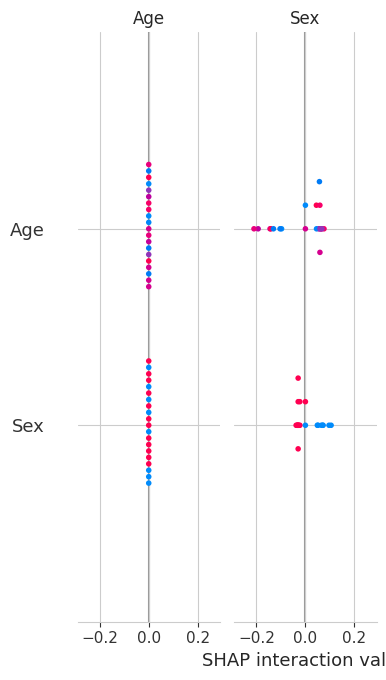

In [22]:
fn = {
    'age': 'Age', 'sex': 'Sex', 'trestbps': 'Resting BP', 'chol': 'Cholesterol',
    'fbs': 'Fasting Sugar', 'thalach': 'Max Heart Rate', 'exang': 'Exercise Angina',
    'oldpeak': 'ST Depression', 'slope': 'ST Slope', 'ca': 'Major Vessels',
    'cp_1': 'Chest Pain (Atypical)', 'cp_2': 'Chest Pain (Non-anginal)',
    'cp_3': 'Chest Pain (Asymptomatic)', 'restecg_1': 'ECG (ST-T Abnormality)',
    'restecg_2': 'ECG (LV Hypertrophy)', 'thal_1': 'Thal (Fixed)',
    'thal_2': 'Thal (Reversible)', 'thal_3': 'Thal (Not Described)',
}

X_display = X_test_scaled[:20].copy()
X_display.columns = [fn.get(c, c) for c in X_display.columns]

if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

shap.summary_plot(sv, X_display, plot_type='bar', show=True)

## 7. Save Model for Production

In [23]:
os.makedirs('../model', exist_ok=True)

with open('../model/best_svm_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('../model/boxcox_lambdas.pkl', 'wb') as f:
    pickle.dump(lambdas, f)

model_size = os.path.getsize('../model/best_svm_model.pkl') / 1024
print(f'Model saved: model/best_svm_model.pkl ({model_size:.1f} KB)')
print(f'Lambdas saved: model/boxcox_lambdas.pkl')
print(f'\nThese files are loaded by the ML microservice (app.py) at runtime.')

Model saved: model/best_svm_model.pkl (23.7 KB)
Lambdas saved: model/boxcox_lambdas.pkl

These files are loaded by the ML microservice (app.py) at runtime.


## Summary

| Metric | Value |
|--------|-------|
| **Algorithm** | Support Vector Machine (SVM) |
| **Kernel** | RBF / Linear (selected by GridSearch) |
| **Dataset** | UCI Heart Disease (Cleveland) |
| **Features** | 13 clinical parameters -> 18 after encoding |
| **Preprocessing** | Box-Cox + StandardScaler |
| **Explainability** | SHAP (SHapley Additive exPlanations) |
| **Deployment** | Flask microservice -> Render cloud |